In [1]:
import sys
sys.executable

'c:\\Users\\pc\\AppData\\Local\\Programs\\Python\\Python312\\python.exe'

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from typing import List, Tuple, Optional
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import timm
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import mean_absolute_error, confusion_matrix
from tqdm import tqdm

## Imports et configuration globale

On importe tout ce dont on a besoin et on définit les hyperparamètres globaux regoupés ici pour faciliter leur modification apres

In [3]:
CFG = {'csv_path': 'df_final_nv.csv',
    'image_root': 'troisieme_approche/binarisation_adaptive',
    'save_dir': 'checkpoints',
    'num_workers': 0,
    'task': 'regression',
    'n_directions': 8,     #nbre de directions de projection
    'mojette_len' : 256,
    'img_moj_size': 128,  
    'embed_dim': 128, 
    'dropout': 0.3,
    'n_epochs': 30,
    'batch_size': 16,
    'lr': 1e-4,
    'n_splits': 5, 
    'seed': 42,}
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device utilisé:{DEVICE}")
torch.manual_seed(CFG['seed'])
np.random.seed(CFG['seed'])
Path(CFG['save_dir']).mkdir(exist_ok=True)

Device utilisé:cpu


## 2. Chargement et exploration du dataset

In [4]:
df = pd.read_csv(CFG['csv_path'])
df = df.dropna(subset=['age'])
print(f"Nombre d'échantillons:{len(df)}")
print(f"Colonnes:{list(df.columns)}")
print(f"\nDistribution des âges:")
print(df['age'].value_counts().sort_index())

Nombre d'échantillons:1002
Colonnes:['serialno', 'no', 'weight', 'length', 'age', 'sex', 'stage', 'liverweight', 'gonadweight', 'spawningage', 'spawningzones', 'readability', 'otolithedge', 'otolithtype_2', 'otolithtype_4', 'otolithtype_5']

Distribution des âges:
age
1.0      37
2.0      46
3.0      64
4.0      82
5.0      90
6.0     126
7.0     144
8.0     119
9.0      93
10.0     54
11.0     46
12.0     61
13.0     18
14.0     15
15.0      4
16.0      3
Name: count, dtype: int64


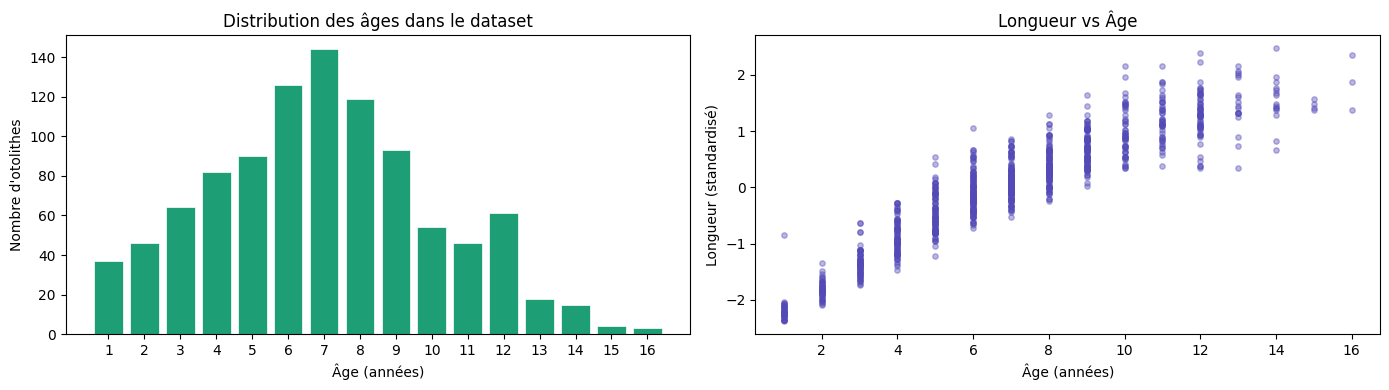

In [5]:
fig,axes = plt.subplots(1,2,figsize=(14,4))

age_counts = df['age'].value_counts().sort_index()
axes[0].bar(age_counts.index, age_counts.values, color='#1D9E75', edgecolor='white', linewidth=0.5)
axes[0].set_xlabel('Âge (années)')
axes[0].set_ylabel('Nombre d\'otolithes')
axes[0].set_title('Distribution des âges dans le dataset')
axes[0].set_xticks(age_counts.index)

axes[1].scatter(df['age'], df['length'], alpha=0.4, s=15, color='#534AB7')
axes[1].set_xlabel('Âge (années)')
axes[1].set_ylabel('Longueur (standardisé)')
axes[1].set_title('Longueur vs Âge')
plt.tight_layout()
plt.savefig('data_exploration.png',dpi=120,bbox_inches='tight')
plt.show()

## 3. La Transformée de Mojette

### Principe mathématique

La **Transformée de Mojette** est une transformée de Radon **discrète et exacte** sur grille entière. Elle projette une image 2D selon des directions rationnelles $(p, q)$.

**Formule** : pour une direction $(p, q)$, le bin d'indice $b$ vaut :
$$M_{(p,q)}[b] = \sum_{(i,j) \in \text{grille}} f[i,j] \cdot \delta(b - (j \cdot p - i \cdot q))$$

Autrement dit, on **somme tous les pixels qui se trouvent sur la même droite discrète** de pente $p/q$.

### Pourquoi pour les otolithes ?

Les otolithes ont des **stries de croissance annulaires** orientées selon un angle dépendant de la coupe. La Mojette :
- **Détecte directionnellement** ces stries : la projection perpendiculaire aux stries produit un signal périodique dont l'espacement = le nombre d'anneaux = l'âge
- Est **exacte** (pas d'interpolation), contrairement à la FFT ou à la transformée de Radon continue
- Produit une représentation **compacte** (8 profils de 256 bins) bien adaptée à un CNN 1D

In [7]:
def mojette_projection_fast(image: np.ndarray, p: int, q: int)->np.ndarray:
    H,W=image.shape
    j_idx=np.arange(W)#shape(W,)
    i_idx=np.arange(H)#shape(H,)
    #calcul vectorisé de b pour chaque pixel en grille (H,W)
    #broadcasting
    b_grid=j_idx[None, :]*p-i_idx[:,None]*q  
    #translation pour avoir des indices positifs
    b_min=int(b_grid.min())
    b_max=int(b_grid.max())
    n_bins=b_max-b_min+1
    #aplatissement
    b_flat=(b_grid-b_min).ravel().astype(np.int32)
    img_flat= image.ravel().astype(np.float32)
    bins=np.bincount(b_flat,weights=img_flat,minlength=n_bins)
    return bins.astype(np.float32)
def mojette_transform(image: np.ndarray,
    directions:Optional[List[Tuple[int,int]]] = None,
    target_length:int=256) -> np.ndarray:
    if directions is None:
        directions =[(0,1),(1,2),(1,1),(2,1),(1,0),(-1,1),(-1,2),(-2,1)]
    projections=[]
    for p,q in directions:
        #projection brute
        proj=mojette_projection_fast(image,p,q)
        #normalisation pour invariance à la luminosité
        norm = np.linalg.norm(proj)
        if norm>1e-8:
            proj=proj/norm
        #interpolation à target_length
        if len(proj)!=target_length:
            proj_t=torch.tensor(proj).unsqueeze(0).unsqueeze(0)
            proj_r=F.interpolate(proj_t, size=target_length,mode='linear', align_corners=False)
            proj = proj_r.squeeze().numpy()
        projections.append(proj)
    return np.stack(projections, axis=0) 

### 3.1 Visualisation de la Transformée de Mojette

On visualise d'abord la Mojette sur une image synthétique simulant des **stries d'otolithe** (anneaux de croissance), puis sur une vraie image du dataset si disponible (test au dessous)

Image trouvée : troisieme_approche\binarisation_adaptive\70025\Nr01_age04\image_0deg.png


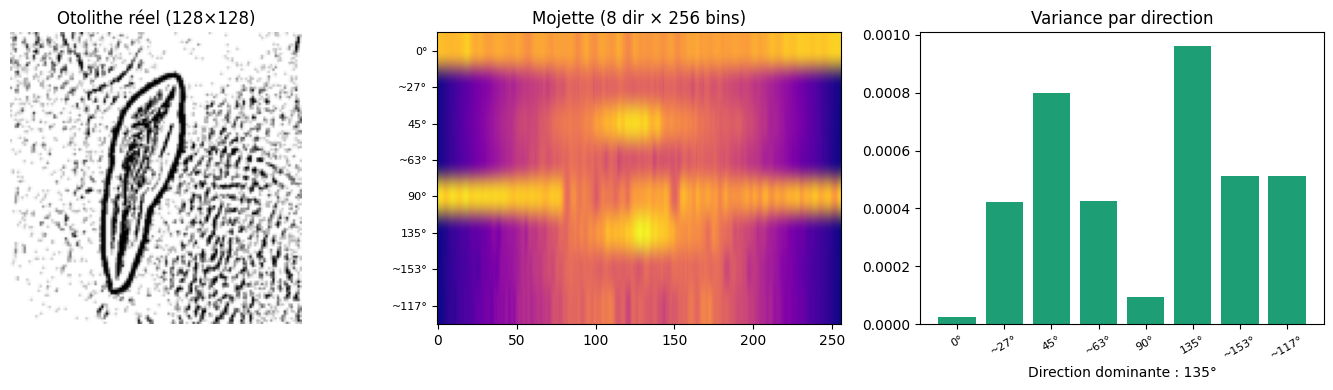

In [8]:
#visualisation sur une vraie image
directions = [(0,1),(1,2),(1,1),(2,1),(1,0),(-1,1),(-1,2),(-2,1)]
dir_labels = ['0°','~27°','45°','~63°','90°','135°','~153°','~117°']
image_root = Path(CFG['image_root'])
if image_root.exists():
    all_imgs=list(image_root.rglob('*.jpg')) + list(image_root.rglob('*.png'))
    if all_imgs:
        sample_path = all_imgs[0]
        print(f"Image trouvée : {sample_path}")
        pil_img=Image.open(sample_path).convert('L')
        img_small=np.array(pil_img.resize((128, 128)), dtype=np.float32) / 255.0
        moj_real=mojette_transform(img_small, directions, target_length=CFG['mojette_len'])
        fig,axes=plt.subplots(1,3,figsize=(14, 4))
        axes[0].imshow(img_small, cmap='gray')
        axes[0].set_title('Otolithe réel (128×128)')
        axes[0].axis('off')
        axes[1].imshow(moj_real, aspect='auto', cmap='plasma')
        axes[1].set_title('Mojette (8 dir × 256 bins)')
        axes[1].set_yticks(range(len(dir_labels)))
        axes[1].set_yticklabels(dir_labels, fontsize=8)
        variances_real = moj_real.var(axis=1)
        axes[2].bar(dir_labels, variances_real, color='#1D9E75')
        axes[2].set_title('Variance par direction')
        axes[2].tick_params(axis='x', rotation=30, labelsize=8)
        best_dir = dir_labels[variances_real.argmax()]
        axes[2].set_xlabel(f'Direction dominante : {best_dir}')
        plt.tight_layout()
        plt.savefig('mojette_real_otolith.png', dpi=120, bbox_inches='tight')
        plt.show()
    else:
        print("Aucune image trouvé")
else:
    print(f"Dossier images non trouvé : {image_root}")

## 4. Dataset PyTorch
Si l'image est absente (dossier manquant), des **tenseurs nuls** sont utilisés en fallback : l'entraînement peut quand même se faire avec les features tabulaires

In [14]:
# Colonnes tabulaires utilisées comme features biométriques
# Elles sont déjà standardisées dans df_final_nv.csv (moyenne=0, std=1)
TABULAR_COLS = [
    'weight', #Poids du poisson
    'length', #Longueur
    'liverweight', #Poids du foie (proxy condition corporelle)
    'gonadweight', #Poids des gonades (maturité sexuelle)
    'spawningage',  #Age à la première ponte
    'spawningzones', #Nombre de zones de ponte
    'readability', #Lisibilité de l'otolithe (qualité image)
    'otolithtype_2', #Type d'otolithe (encodage one-hot)
    'otolithtype_4',
    'otolithtype_5',]
#transformation standard pour EfficientNet
#resize 224x224 (taille attendue par EfficientNet-B0)
#normalisation: mean=0.5, std=0.5 pour image en niveaux de gris
IMAGE_TRANSFORM = transforms.Compose([transforms.Grayscale(num_output_channels=1),transforms.Resize((224, 224)),transforms.ToTensor(),
                                      transforms.Normalize(mean=[0.5], std=[0.5]),])
class OtolithDataset(Dataset):
    def __init__(
        self,
        df: pd.DataFrame,
        image_root: str,
        mojette_directions=None,
        mojette_target_len: int = 256,
        img_moj_size: int = 128,
        task: str='regression',
        transform=None,):
        self.df=df.reset_index(drop=True)
        self.image_root=Path(image_root)
        self.directions=mojette_directions
        self.mojette_len=mojette_target_len
        self.img_moj_size=img_moj_size
        self.task = task
        self.transform= transform or IMAGE_TRANSFORM
        #nombre de directions (pour les fallback tenseurs nuls)
        n_dir = len(self.directions) if self.directions else 8
        self.n_directions = n_dir
        #pour la classification : mapping âge → indice 0-N
        if task=='classification':
            self.age_classes = sorted(df['age'].unique())
            self.age_to_idx  = {a: i for i, a in enumerate(self.age_classes)}
            print(f"Classes d'âge ({len(self.age_classes)}) : {self.age_classes}")
    def _find_image(self, serialno: int, no: int, age: float) -> Optional[Path]:
        """Là je Cherche le fichier image dans la structure Nr<no>_age<age>."""
        folder=self.image_root / str(serialno) / f"Nr{no:02d}_age{int(age):02d}"
        if not folder.exists():
            return None
        for ext in ['*.jpg', '*.jpeg', '*.png', '*.tif', '*.tiff']:
            imgs=list(folder.glob(ext))
            if imgs:
                return imgs[0]  # on prend la first image du dossier
        return None
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row=self.df.iloc[idx]
        tab_feats=torch.tensor(
            row[TABULAR_COLS].values.astype(np.float32),
            dtype=torch.float32
        )
        img_path=self._find_image(int(row['serialno']), int(row['no']), row['age'])
        if img_path is not None:
            pil_img=Image.open(img_path).convert('L')   
            img_tensor=self.transform(pil_img)              
            img_small =np.array(
                pil_img.resize((self.img_moj_size, self.img_moj_size)),
                dtype=np.float32
            ) / 255.0
            moj = mojette_transform(img_small, self.directions, self.mojette_len)
            moj_tensor=torch.tensor(moj, dtype=torch.float32) 
        else:
            # Fallback tenseurs nuls si image introuvable
            img_tensor=torch.zeros(1, 224, 224, dtype=torch.float32)
            moj_tensor=torch.zeros(self.n_directions, self.mojette_len,
                                     dtype=torch.float32)
        if self.task == 'regression':
            label=torch.tensor(row['age'], dtype=torch.float32)
        else:
            label=torch.tensor(self.age_to_idx[row['age']], dtype=torch.long)

        return {
            'image':img_tensor,
            'mojette':moj_tensor,
            'tabular':tab_feats,
            'label':label,}

#juste pour tester sans img
ds_test=OtolithDataset(df.head(5), CFG['image_root'], task=CFG['task'])
sample=ds_test[0]
print(f"\nTest:")
for k,v in sample.items():
    print(f"{k:1s}:shape={tuple(v.shape)}, dtype={v.dtype}")


Test:
image:shape=(1, 224, 224), dtype=torch.float32
mojette:shape=(8, 256), dtype=torch.float32
tabular:shape=(10,), dtype=torch.float32
label:shape=(), dtype=torch.float32


## 5. Architecture du modèle hybride

### 5.1 Encodeur Mojette (CNN 1D)

Les profils Mojette (8, 256) sont traités par un CNN 1D. L'idée : les pics dans les profils correspondent aux stries, et leur espacement encode l'âge. Le CNN apprend à détecter ces patterns périodiques.

Architecture : 3 couches Conv1D avec BatchNorm + GELU → AvgPool global → projection linéaire

In [15]:
class MojetteEncoder(nn.Module):
    def __init__(self, n_directions: int = 8, seq_len: int = 256, embed_dim: int = 128):
        super().__init__()
        # 3 couches convolutives 1D
        self.conv = nn.Sequential(
            nn.Conv1d(n_directions, 32, kernel_size=7, padding=3),
            nn.BatchNorm1d(32),
            nn.GELU(),
            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.GELU(),
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.GELU(),)
        #sortie de taille fixe quelle que soit la longueur des profils
        self.pool = nn.AdaptiveAvgPool1d(1)
        # Projection vers embed_dim
        self.proj = nn.Linear(128, embed_dim)
    def forward(self, x):
        # x : (B, n_dir, seq_len)
        x=self.conv(x) # (B,128,inutile seq)
        x=self.pool(x)# (B,128,1)
        x=x.squeeze(-1)  # (B,128)
        return self.proj(x) # (B,embed_dim)
print("MojetteEncoder défini")

# Vérification des dimensions
enc=MojetteEncoder(n_directions=8,seq_len=256,embed_dim=CFG['embed_dim'])
dummy=torch.zeros(2,8,256)
out=enc(dummy)
print(f"Test MojetteEncoder:{tuple(dummy.shape)} en {tuple(out.shape)}")

MojetteEncoder défini
Test MojetteEncoder:(2, 8, 256) en (2, 128)


### 5.2 Modèle hybride complet

Les trois branches sont fusionnées par concaténation puis traitées par un MLP de fusion.

**Pourquoi la concaténation ?**  
Elle préserve toute l'information de chaque branche la concaténation est le point de départ le plus robuste.

**Choix de la tâche :**
- regression : la sortie est un float (MAE typiquement 0.5–1 an pour des modèles similaires)
- classification : la sortie est une distribution sur les 16 classes d'âge

In [18]:
class HybridOtolithModel(nn.Module):
    def __init__(
        self,
        n_tabular  : int = 10,
        n_directions: int = 8,
        mojette_len : int = 256,
        embed_dim : int = 128,
        n_classes   : int = 1,      
        task  : str = 'regression',
        dropout : float = 0.3,
    ):
        super().__init__()
        self.task = task
        self.efficientnet = timm.create_model('efficientnet_b0',
            pretrained=True,   
            in_chans=1,        #adapte la premiere conv pour image en nv de gris
            num_classes=0,     
        )
        self.img_proj = nn.Sequential(
            nn.Linear(1280, embed_dim),
            nn.LayerNorm(embed_dim),
            nn.GELU(),)
        self.mojette_enc = MojetteEncoder(n_directions, mojette_len, embed_dim)
        self.tab_enc = nn.Sequential(
            nn.Linear(n_tabular, 64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, embed_dim),
            nn.LayerNorm(embed_dim),
            nn.GELU(),)
        fusion_dim = 3 * embed_dim
        self.fusion = nn.Sequential(
            nn.Linear(fusion_dim, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.GELU(),)
        self.head = nn.Linear(128, n_classes)
    def forward(self, image, mojette, tabular):
        img_emb=self.img_proj(self.efficientnet(image))  
        moj_emb=self.mojette_enc(mojette)               
        tab_emb=self.tab_enc(tabular)                  

        fused=torch.cat([img_emb, moj_emb, tab_emb], dim=1) 
        fused=self.fusion(fused)                              
        out=self.head(fused)                               
        return out.squeeze(-1) if self.task == 'regression' else out
#test vite fait
model_test = HybridOtolithModel(task='regression')
model_test.eval()
with torch.no_grad():
    out_test = model_test(
        torch.zeros(2, 1, 224, 224),
        torch.zeros(2, 8, 256),
        torch.zeros(2, 10))
def count_params(module):
    return sum(p.numel() for p in module.parameters() if p.requires_grad)
print(f"\nParamètres entrainables :")
print(f"EfficientNet + proj:{count_params(model_test.efficientnet) + count_params(model_test.img_proj):,}")
print(f"MojetteEncoder:{count_params(model_test.mojette_enc):,}")
print(f"MLP tabulaire:{count_params(model_test.tab_enc):,}")
print(f"Fusion + tête:{count_params(model_test.fusion) + count_params(model_test.head):,}")
print(f"Total:{count_params(model_test):,}")
del model_test


Paramètres entrainables :
EfficientNet + proj:4,171,196
MojetteEncoder:53,792
MLP tabulaire:9,280
Fusion + tête:132,097
Total:4,366,365


## 6. Fonctions d'entraînement et d'évaluation

- **train_one_epoch** : une passe complète sur le dataset d'entraînement avec rétropropagation
- **evaluate** : passe inférence sans gradient sur le dataset de validation
- **Loss** : Huber Loss pour la régression (robuste aux valeurs aberrantes, moins sensible que le MSE)
- **Gradient clipping** : limite les gradients à 1.0 pour éviter les explosions pendant la backprop

In [19]:
def train_one_epoch(model, loader, optimizer, criterion, device, task):
    model.train()
    total_loss = 0.0
    for batch in tqdm(loader, desc='  Train', leave=False):
        image=batch['image'].to(device)
        mojette=batch['mojette'].to(device)
        tabular=batch['tabular'].to(device)
        label=batch['label'].to(device)
        optimizer.zero_grad()                                
        pred=model(image, mojette, tabular)                   
        loss=criterion(pred, label) # calcul du loss
        loss.backward() # backpropagation
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0) 
        optimizer.step()                                        
        total_loss+=loss.item()                                 
    return total_loss/len(loader)

@torch.no_grad()
def evaluate(model, loader, criterion, device, task):
    model.eval()          
    total_loss = 0.0
    preds_all, labels_all = [], []
    for batch in loader:
        image= batch['image'].to(device)
        mojette= batch['mojette'].to(device)
        tabular= batch['tabular'].to(device)
        label= batch['label'].to(device)
        pred=model(image, mojette, tabular)
        loss=criterion(pred, label)
        total_loss += loss.item()
        if task=='regression':
            preds_all.extend(pred.cpu().numpy().tolist())
        else:
            preds_all.extend(pred.argmax(dim=-1).cpu().numpy().tolist())
        labels_all.extend(label.cpu().numpy().tolist())
    preds_all=np.array(preds_all)
    labels_all=np.array(labels_all)
    avg_loss= total_loss / len(loader)
    if task== 'regression':
        mae=float(np.mean(np.abs(preds_all - labels_all)))
        return {'loss': avg_loss, 'MAE_ans': mae}
    else:
        acc=float((preds_all == labels_all).mean())
        return {'loss': avg_loss, 'accuracy': acc}

## 7. Entraînement avec cross-validation stratifiée

On utilise une **cross-validation en 5 folds stratifiée** sur l'âge :
- **Stratifié** = chaque fold contient la même proportion d'âges que le dataset complet (important car les âges 1 et 16 sont rares)
- **5 folds** = 80% entraînement / 20% validation à chaque fold

**Scheduler Cosine Annealing** : fait décroître le learning rate suivant une courbe cosinus de `lr` à `lr/100`. Évite les oscillations en fin d'entraînement et améliore la convergence.


In [ ]:
TASK       = CFG['task']      
N_CLASSES  = 1 if TASK == 'regression' else df['age'].nunique()
N_TABULAR  = len(TABULAR_COLS)
skf = StratifiedKFold(
    n_splits=CFG['n_splits'],
    shuffle=True,
    random_state=CFG['seed'])
all_fold_metrics= [] #métriques fin de chaque fold
all_fold_history= []#courbes loss/métrique de chaque fold
for fold, (train_idx, val_idx) in enumerate(
    skf.split(df, df['age'].astype(int))):
    print(f"\n{'─'*60}")
    print(f"Fold {fold + 1}/{CFG['n_splits']}  │  train={len(train_idx)}  val={len(val_idx)}")
    print(f"{'─'*60}")
    df_train = df.iloc[train_idx]
    df_val   = df.iloc[val_idx]
    ds_train = OtolithDataset(
        df_train, CFG['image_root'],
        mojette_target_len=CFG['mojette_len'],
        img_moj_size=CFG['img_moj_size'],
        task=TASK)
    ds_val = OtolithDataset(
        df_val, CFG['image_root'],
        mojette_target_len=CFG['mojette_len'],
        img_moj_size=CFG['img_moj_size'],
        task=TASK)
    train_loader = DataLoader(
    ds_train, batch_size=CFG['batch_size'],
    shuffle=True, num_workers=0, pin_memory=False, drop_last=True)
    val_loader = DataLoader(
    ds_val, batch_size=CFG['batch_size'],
    shuffle=False, num_workers=0, pin_memory=False)
    model = HybridOtolithModel(
        n_tabular= N_TABULAR,
        n_directions= CFG['n_directions'],
        mojette_len = CFG['mojette_len'],
        embed_dim= CFG['embed_dim'],
        n_classes= N_CLASSES,
        task= TASK,
        dropout= CFG['dropout'],).to(DEVICE)
    #optimiseur Adamw
    optimizer = torch.optim.AdamW(model.parameters(), lr=CFG['lr'], weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CFG['n_epochs'], eta_min=CFG['lr'] / 100)
    #Huber Loss (régression) car plus robuste que MSE aux valeurs aberrantes
    if TASK == 'regression':
        criterion = nn.HuberLoss(delta=1.0)
    else:
        criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    best_val_loss = float('inf')
    fold_history  = {'train_loss': [], 'val_loss': [], 'val_metric': []}
    save_path     = Path(CFG['save_dir']) / f'fold{fold}_best.pth'
    for epoch in range(CFG['n_epochs']):
        train_loss  = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE, TASK)
        val_metrics = evaluate(model, val_loader, criterion, DEVICE, TASK)
        scheduler.step()
        metric_key = 'MAE_ans' if TASK == 'regression' else 'accuracy'
        metric_val = val_metrics[metric_key]
        fold_history['train_loss'].append(train_loss)
        fold_history['val_loss'].append(val_metrics['loss'])
        fold_history['val_metric'].append(metric_val)
        if val_metrics['loss'] < best_val_loss:
            best_val_loss = val_metrics['loss']
            torch.save(model.state_dict(), save_path)
            best_tag = '  ← meilleur'
        else:
            best_tag = ''
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"  Epoch {epoch+1:3d}/{CFG['n_epochs']}  "
                  f"train_loss={train_loss:.4f}  "
                  f"val_loss={val_metrics['loss']:.4f}  "
                  f"{metric_key}={metric_val:.4f}"
                  f"{best_tag}")
    all_fold_history.append(fold_history)
    all_fold_metrics.append({'fold': fold + 1, **val_metrics})
    print(f"  Meilleur modèle sauvegardé : {save_path}")
print(f"\n{'═'*60}")
print(" Résultats cross-validation")
print(f"{'═'*60}")
metrics_df = pd.DataFrame(all_fold_metrics)
print(metrics_df.to_string(index=False))
metric_key = 'MAE_ans' if TASK == 'regression' else 'accuracy'
vals = metrics_df[metric_key].values
print(f"\n{metric_key} moyen : {vals.mean():.4f} ± {vals.std():.4f}")

c:\Users\pc\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(



────────────────────────────────────────────────────────────
 Fold 1/5  │  train=801  val=201
────────────────────────────────────────────────────────────


  Epoch   1/30  train_loss=4.8887  val_loss=3.8195  MAE_ans=4.2036  ← meilleur


  Epoch   5/30  train_loss=0.5627  val_loss=0.3591  MAE_ans=0.6761  ← meilleur


  Epoch  10/30  train_loss=0.3129  val_loss=0.2139  MAE_ans=0.4863  ← meilleur


...

  Epoch  10/30  train_loss=0.3463  val_loss=0.1984  MAE_ans=0.4828


  Epoch  15/30  train_loss=0.2730  val_loss=0.1545  MAE_ans=0.4117  ← meilleur


  Epoch  20/30  train_loss=0.2414  val_loss=0.1589  MAE_ans=0.4155


  Epoch  25/30  train_loss=0.2386  val_loss=0.1373  MAE_ans=0.3828  ← meilleur


  Epoch  30/30  train_loss=0.2091  val_loss=0.1364  MAE_ans=0.3784
  Meilleur modèle sauvegardé : checkpoints\fold4_best.pth

════════════════════════════════════════════════════════════
 Résultats cross-validation
════════════════════════════════════════════════════════════
 fold     loss  MAE_ans
    1 0.176365 0.437253
    2 0.131756 0.370096
    3 0.108189 0.342034
    4 0.188956 0.456448
    5 0.136386 0.378413

MAE_ans moyen : 0.3968 ± 0.0430


## 8. Visualisation des résultats d'entraînement

On trace les courbes de loss et de métrique par fold pour diagnostiquer :
- **Surapprentissage** : la val_loss remonte alors que la train_loss continue de baisser
- **Sous-apprentissage** : les deux losses restent élevées
- **Convergence** : les courbes se stabilisent

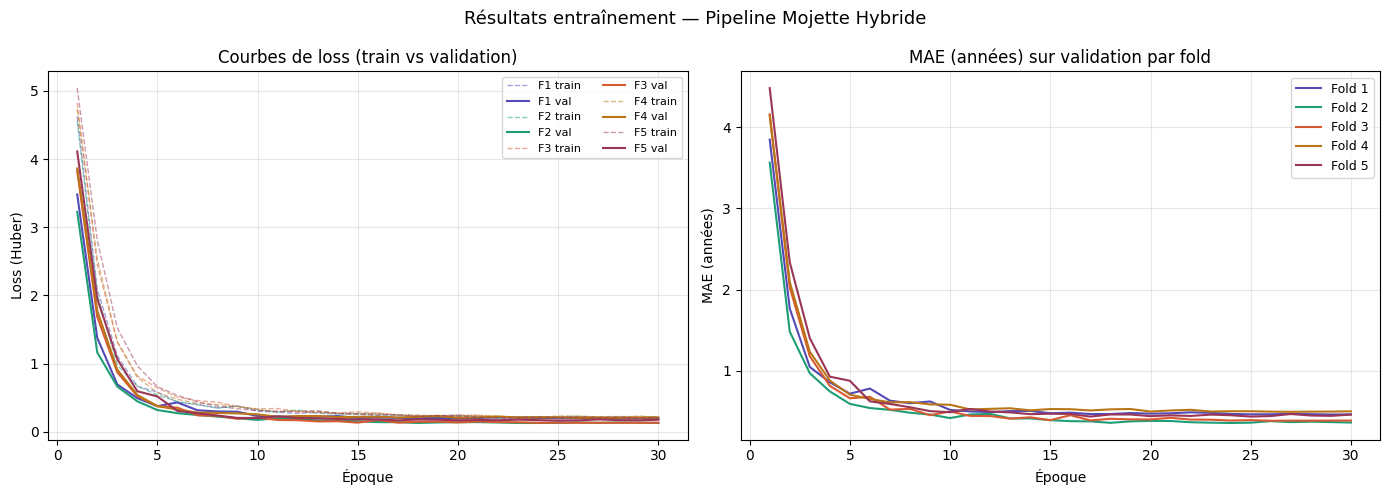

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#534AB7', '#1D9E75', '#D85A30', '#BA7517', '#993556']
metric_key   = 'MAE_ans' if CFG['task'] == 'regression' else 'accuracy'
metric_label = 'MAE (années)' if CFG['task'] == 'regression' else 'Accuracy'
for fold, history in enumerate(all_fold_history):
    c = colors[fold % len(colors)]
    epochs = range(1, len(history['train_loss']) + 1)
    axes[0].plot(epochs, history['train_loss'], color=c, linestyle='--',alpha=0.5, linewidth=1, label=f'F{fold+1} train')
    axes[0].plot(epochs, history['val_loss'], color=c, linewidth=1.5,label=f'F{fold+1} val')
    axes[1].plot(epochs, history['val_metric'], color=c, linewidth=1.5,label=f'Fold {fold+1}')
axes[0].set_title('Courbes de loss (train vs validation)')
axes[0].set_xlabel('Époque')
axes[0].set_ylabel('Loss (Huber)')
axes[0].legend(fontsize=8, ncol=2)
axes[0].grid(alpha=0.3)
axes[1].set_title(f'{metric_label} sur validation par fold')
axes[1].set_xlabel('Époque')
axes[1].set_ylabel(metric_label)
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)
plt.suptitle('Résultats entraînement — Pipeline Mojette Hybride', fontsize=13)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=120, bbox_inches='tight')
plt.show()

## 9. Inférence et analyse des erreurs

On charge le meilleur modèle du fold 0 et on prédit sur l'ensemble du dataset pour analyser les erreurs par classe d'âge.

**Erreurs typiques attendues :**
- Ages extrêmes (1 an et 16 ans) : sous-représentés donc moins bien prédits
- Ages proches (ex. 7 vs 8) : plus difficiles à distinguer

Inférence: 100%|██████████| 32/32 [00:26<00:00,  1.20it/s]


MAE globale : 0.2918 ans


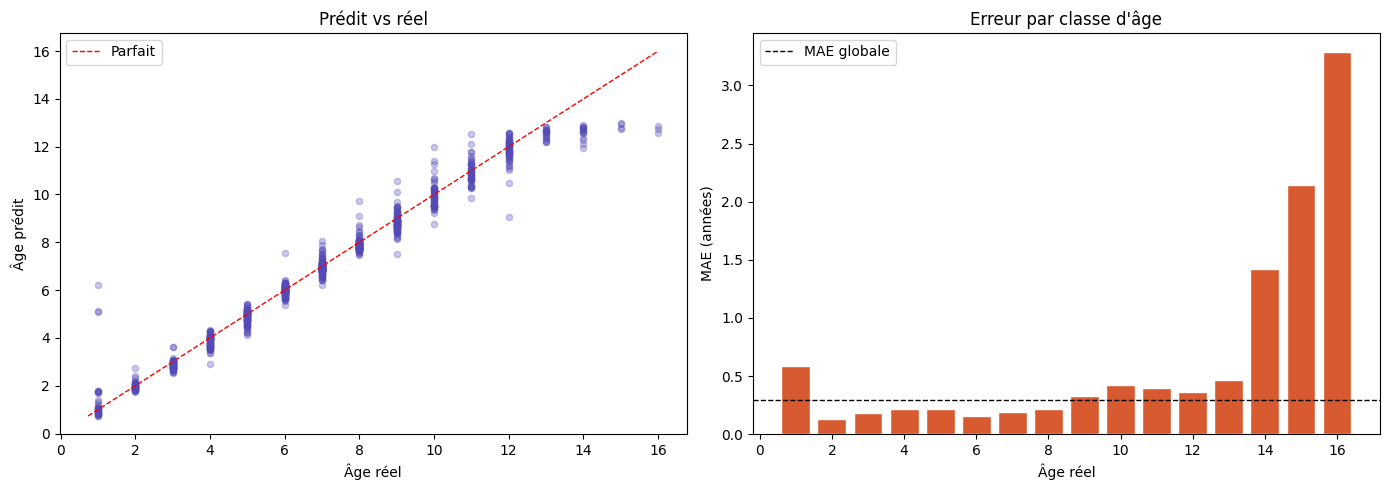

In [ ]:
# Chargement du meilleur modèle (fold 0)
best_model_path = Path(CFG['save_dir']) / 'fold0_best.pth'

if best_model_path.exists():
    best_model = HybridOtolithModel(
        n_tabular   = N_TABULAR,
        n_directions= CFG['n_directions'],
        mojette_len = CFG['mojette_len'],
        embed_dim   = CFG['embed_dim'],
        n_classes   = N_CLASSES,
        task        = TASK,).to(DEVICE)
    best_model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
    best_model.eval()
    ds_full  = OtolithDataset(df, CFG['image_root'], task=TASK)
    full_loader = DataLoader(ds_full, batch_size=32, shuffle=False, num_workers=0)

    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in tqdm(full_loader, desc='Inférence'):
            pred = best_model(batch['image'].to(DEVICE),
                batch['mojette'].to(DEVICE),
                batch['tabular'].to(DEVICE))
            all_preds.extend(pred.cpu().numpy().tolist())
            all_labels.extend(batch['label'].cpu().numpy().tolist())
    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    if TASK == 'regression':
        # Scatter prédit vs réel
        axes[0].scatter(all_labels, all_preds, alpha=0.3, s=20, color='#534AB7')
        lims = [min(all_labels.min(), all_preds.min()), max(all_labels.max(), all_preds.max())]
        axes[0].plot(lims, lims, 'r--', linewidth=1, label='Parfait')
        axes[0].set_xlabel('Âge réel')
        axes[0].set_ylabel('Âge prédit')
        axes[0].set_title('Prédit vs réel')
        axes[0].legend()
        # MAE par classe d'âge
        ages_unique = sorted(np.unique(all_labels))
        mae_by_age  = [
            np.mean(np.abs(all_preds[all_labels == a] - a))
            for a in ages_unique]
        axes[1].bar(ages_unique, mae_by_age, color='#D85A30', edgecolor='white')
        axes[1].axhline(np.mean(np.abs(all_preds - all_labels)),color='black', linestyle='--', linewidth=1, label='MAE globale')
        axes[1].set_xlabel('Âge réel')
        axes[1].set_ylabel('MAE (années)')
        axes[1].set_title('Erreur par classe d\'âge')
        axes[1].legend()
    else:
        # Matrice de confusion (classification)
        cm     = confusion_matrix(all_labels, all_preds)
        cm_pct = cm.astype(float)/cm.sum(axis=1, keepdims=True)
        im = axes[0].imshow(cm_pct, cmap='Blues')
        plt.colorbar(im, ax=axes[0])
        ages_u = sorted(np.unique(all_labels))
        axes[0].set_xticks(range(len(ages_u)))
        axes[0].set_yticks(range(len(ages_u)))
        axes[0].set_xticklabels([int(a) for a in ages_u], fontsize=7)
        axes[0].set_yticklabels([int(a) for a in ages_u], fontsize=7)
        axes[0].set_xlabel('Prédit')
        axes[0].set_ylabel('Réel')
        axes[0].set_title('Matrice de confusion (% ligne)')
    print(f"MAE globale : {np.mean(np.abs(all_preds - all_labels)):.4f} ans")
    plt.tight_layout()
    plt.savefig('error_analysis.png', dpi=120, bbox_inches='tight')
    plt.show()
else:
    print(f"Modele non trouvé : {best_model_path}")
    print("Lancez la cellule d'entraînement d'abord.")

## 10. Inférence sur un seul otolithe

Exemple d'utilisation en production : prédire l'âge d'un otolithe à partir de son image et de ses données biométriques.

In [ ]:
@torch.no_grad()
def predict_single(
    image_path: str,
    tabular_values: dict,
    model: nn.Module,
    device: str = 'cpu',) -> float:
    model.eval()
    # Features tabulaires
    tab = np.array([tabular_values[c] for c in TABULAR_COLS], dtype=np.float32)
    tab_tensor= torch.tensor(tab).unsqueeze(0).to(device)  # (1, 10)
    # Image
    pil_img= Image.open(image_path).convert('L')
    img_tensor= IMAGE_TRANSFORM(pil_img).unsqueeze(0).to(device)  # (1,1,224,224)
    # Mojette
    img_small= np.array(pil_img.resize((128, 128)), dtype=np.float32) / 255.0
    moj= mojette_transform(img_small, target_length=CFG['mojette_len'])
    moj_tensor= torch.tensor(moj).unsqueeze(0).to(device)  # (1, 8, 256)
    pred= model(img_tensor, moj_tensor, tab_tensor)
    return float(pred.item())
# Exemple d'utilisation
# Valeurs exemple correspondant à un échantillon du dataset
sample_row = df.iloc[0]
example_tabular= {col: float(sample_row[col]) for col in TABULAR_COLS}
example_image= (Path(CFG['image_root'])/ str(int(sample_row['serialno']))/ f"Nr{int(sample_row['no']):02d}_age{int(sample_row['age']):02d}")
print("Exemple d'inférence :")
print(f"serialno={int(sample_row['serialno'])}, no={int(sample_row['no'])}")
print(f"Âge réel: {sample_row['age']} ans")
print(f"Dossier img: {example_image}")
img_path = None
if example_image.exists():
    for ext in ['*.jpg','*.jpeg','*.png']:
        imgs = list(example_image.glob(ext))
        if imgs:
            img_path = str(imgs[0])
            break
if img_path and best_model_path.exists():
    predicted_age= predict_single(img_path, example_tabular, best_model, DEVICE)
    print(f"Âge prédit:{predicted_age:.2f} ans")
    print(f"Erreur:{abs(predicted_age - sample_row['age']):.2f} ans")

Exemple d'inférence :
  serialno=70029, no=1
  Âge réel    : 6.0 ans
  Dossier img : troisieme_approche\binarisation_adaptive\70029\Nr01_age06
  Âge prédit  : 6.03 ans
  Erreur      : 0.03 ans
